In [1]:
import tensorflow as tf
print(tf.__version__)


2.16.1


In [12]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Sequential

import warnings
warnings.filterwarnings('ignore')

In [6]:
# pip install pandas

In [11]:
# pip install matplotlib


In [10]:
# pip install numpy

In [13]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 33s 3us/step


In [14]:
X_train.shape

(60000, 28, 28)

In [15]:
y_train.shape

(60000,)

In [16]:
X_test.shape

(10000, 28, 28)

In [17]:
y_test.shape

(10000,)

In [18]:
print(keras.datasets.mnist.load_data())
print(len(keras.datasets.mnist.load_data()))

((array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ...

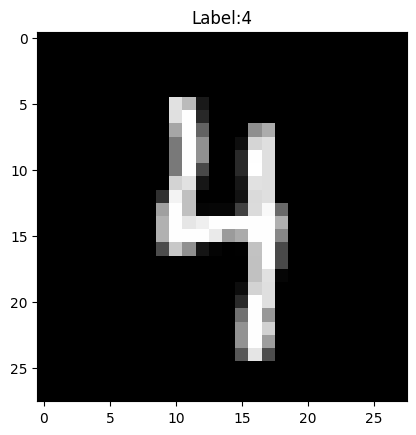

In [22]:
# Lets see visually how digit looks like

plt.imshow(X_train[1110],cmap='gray')
plt.title(f"Label:{y_train[1110]}")
plt.show()

In [23]:
X_train[1008]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [24]:
# Lets normalise the data , in this case need to divide data by 255.0
# Large values → unstable learning
# So we scale to: 0 to 1
# Neural networks learn better with smaller values also improves accuracy

X_train=X_train/255.0
X_test=X_test/255.0

In [25]:
X_train[1008]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [26]:
# ANN doesn’t understand images directly → we convert to vector
# so need to convert image (28x28) into 1D vector
# (not dataset, it will be 2D)

X_train_flattened=X_train.reshape(-1,784)
X_test_flattened=X_test.reshape(-1,784)

In [30]:
X_train_flattened


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [31]:
X_train_flattened.shape

(60000, 784)

In [35]:
# Lets build model
# used dropout to reduce overfitting

model=Sequential(
    [Dense(128,activation='relu',input_shape=(784,)),
     Dropout(0.2),
     Dense(64,activation='relu'),
     Dropout(0.2),
     Dense(32,activation='relu'),
     Dropout(0.2),
     Dense(10,activation='sigmoid')
])

# compile model
# optimizer = 'adam' Automatically adjusts learning rate Works well in most cases

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# Lets train model
# epochs=5 ,Entire dataset is passed 5 times
model.fit(X_train_flattened,y_train,epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8716 - loss: 0.4379
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9436 - loss: 0.2044
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9561 - loss: 0.1611
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9624 - loss: 0.1345
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9670 - loss: 0.1209


In [36]:
# Lets evaluate model  to check real performance (Test Accuracy)
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9736 - loss: 0.0913


[0.09127851575613022, 0.9735999703407288]

In [37]:
y_predict=model.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [38]:
y_predict[0]

array([6.5923133e-04, 5.9191384e-03, 4.1570598e-01, 5.7259905e-01,
       1.0138890e-04, 6.3842144e-03, 1.3274926e-07, 9.9999541e-01,
       6.2638661e-05, 8.6963803e-01], dtype=float32)

In [41]:
print(np.argmax(y_predict[0]))

7


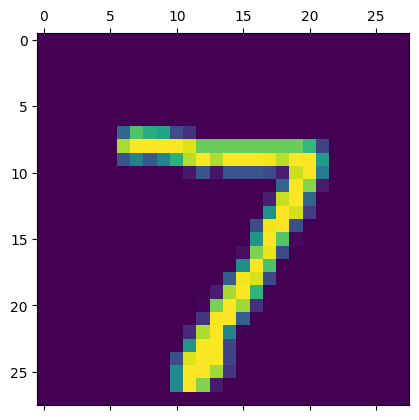

In [43]:
plt.matshow(X_test[0])

In [44]:
model.save("digit_recognition_model.keras")

In [ ]:
pip install streamlit
